In [1]:
import openeo
import json

connection = openeo.connect("openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [2]:
# Show possible connections and save them to .txt

connections_path = 'connection_list.txt'
connections = connection.list_collections()

with open(connections_path, 'w') as file:
    json.dump(connections, file, indent=2, sort_keys=True)

for item in connections:
    print(item.get("id"))

SENTINEL3_OLCI_L1B
SENTINEL3_SLSTR
SENTINEL_5P_L2
COPERNICUS_VEGETATION_PHENOLOGY_PRODUCTIVITY_10M_SEASON1
COPERNICUS_VEGETATION_PHENOLOGY_PRODUCTIVITY_10M_SEASON2
COPERNICUS_PLANT_PHENOLOGY_INDEX
ESA_WORLDCOVER_10M_2020_V1
ESA_WORLDCOVER_10M_2021_V2
SENTINEL1_GRD
COPERNICUS_30
LANDSAT_BIMONTHLY_MOSAIC
SENTINEL3_SYN_L2_SYN
SENTINEL3_SLSTR_L2_LST
SENTINEL1_GLOBAL_MOSAICS
SENTINEL2_L2A
SENTINEL2_L1C
SENTINEL3_OLCI_L2_LAND
SENTINEL3_OLCI_L2_WATER
SENTINEL3_SYN_L2_AOD


In [3]:
# Define rectangle to observe (North>South, East>West)
# bboxfinder.com format: (-5.361328,55.304138,-2.356567,56.194481)
#                        (W, S, E, N)

CITIES = {
    "Dundee": {"west": -3.172302,
               "south": 56.278436,
               "east": -2.598267,
               "north":56.567806
              },
    
    "Central Belt": {"west": -5.361328,
                    "south": 55.304138,
                     "east": -2.356567,
                     "north": 56.194481
                    },

    "Oban": {"west": -6.479187,
             "south": 56.104215,
             "east": -4.990540,
             "north": 56.799374
            }
}


In [4]:
import pandas as pd
import os
import xarray as xr

#Add Location Cache
CACHE_DIR = "cache"
os.makedirs(CACHE_DIR, exist_ok=True)

# Data request
def get_no2(city, start_date, end_date):
    cache_file = f"{CACHE_DIR}/{city}_{start_date}_{end_date}.parquet"

    if os.path.exists(cache_file):
        return pd.read_parquet(cache_file)

    bbox = CITIES[city]

    datacube = connection.load_collection(
        "SENTINEL_5P_L2",
        spatial_extent=bbox,
        temporal_extent=["2024-06-01", "2024-06-28"],
        bands=["NO2"]
    )
    
    datacube.download(f"{CACHE_DIR}/{city}_temp.nc")
    
    ds = xr.open_dataset(f"{CACHE_DIR}/{city}_temp.nc")
    df = ds['NO2'].to_dataframe(name='NO2').reset_index().dropna()
    df = df[df['NO2'] > 0]
    
    df.to_parquet(cache_file)
    print(f"Cached to {cache_file}")
    return df

In [5]:
#Change df_glasgow name!!!!

df_glasgow = get_no2("Central Belt", "2024-06-01", "2024-06-28")
print(df_glasgow.head())
print(f"Shape: {df_glasgow.shape}")

Cached to cache/Central Belt_2024-06-01_2024-06-28.parquet
           t         y         x       NO2
0 2024-06-01  56.17712 -5.334046  0.000025
1 2024-06-01  56.17712 -5.279483  0.000015
2 2024-06-01  56.17712 -5.224919  0.000015
3 2024-06-01  56.17712 -5.170356  0.000026
4 2024-06-01  56.17712 -5.115792  0.000021
Shape: (8483, 4)


In [10]:
# Bring in plots using matplotlib
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

NO2_min = df_glasgow['NO2'].min()
NO2_max = df_glasgow['NO2'].max()
NO2_average = df_glasgow['NO2'].mean()


NO2_min = np.array(NO2_min)
NO2_max = np.array(NO2_max)
NO2_average = np.array(NO2_average)

NO2_min = NO2_min.item()
NO2_max = NO2_max.item()
NO2_average = NO2_average.item()

# Round and print
print(f"Properties of dataset:")
print("==================================================================")
print(" ")
print(f"Range of NO_2 = {NO2_min:.3E} to {NO2_max:.3E} mol/m²")
print(f"Mean value: {NO2_average:.3E} mol/m²")
print(f"Date Range: {df_glasgow['t'].min()} to {df_glasgow['t'].max()}")
print(" ")
print("==================================================================")

Properties of dataset:
 
Range of NO_2 = 1.729E-08 to 9.260E-05 mol/m²
Mean value: 2.164E-05 mol/m²
Date Range: 2024-06-01 00:00:00 to 2024-06-27 00:00:00
 


Best day: 2024-06-01 00:00:00
Averaging over 5 days
Valid pixels: 1417


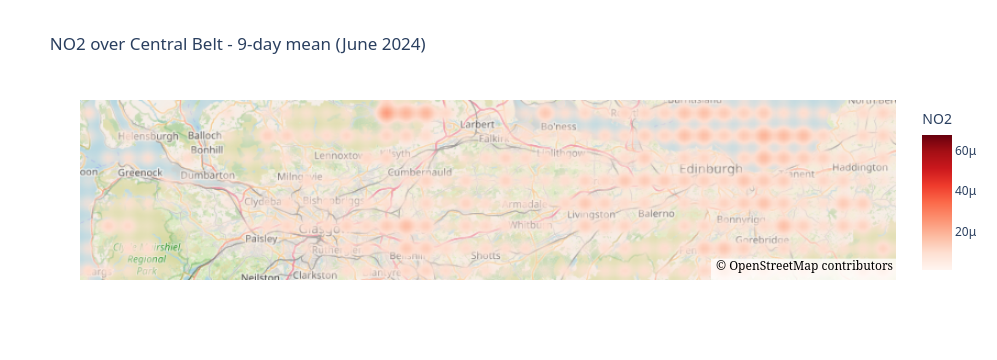

In [14]:
# Find best day
valid_counts = df_glasgow.groupby('t')['NO2'].count()
best_day = valid_counts.idxmax()
print(f"Best day: {best_day}")

# Get +/- 4 day window
all_dates = sorted(df_glasgow['t'].unique())
best_idx = list(all_dates).index(best_day)
t_start = max(0, best_idx - 4)
t_end = min(len(all_dates) - 1, best_idx + 4)
window_dates = all_dates[t_start:t_end + 1]

# Filter and average over window
window_df = df_glasgow[df_glasgow['t'].isin(window_dates)]
no2_mean = window_df.groupby(['x', 'y'])['NO2'].mean().reset_index()

print(f"Averaging over {len(window_dates)} days")
print(f"Valid pixels: {len(no2_mean)}")

fig = px.density_map(
    no2_mean, 
    lat='y', 
    lon='x', 
    z='NO2',
    radius=20,
    center={"lat": 55.92, "lon": -3.8},
    zoom=8,
    map_style="open-street-map",
    title="NO2 over Central Belt - 9-day mean (June 2024)",
    color_continuous_scale="Reds"
)

fig.show()

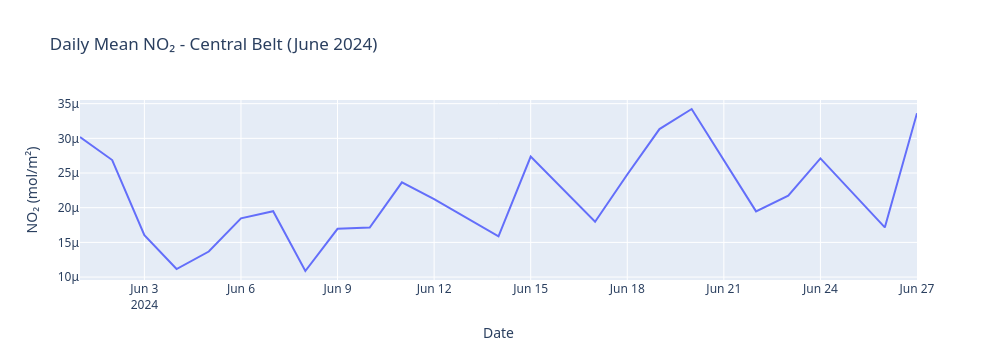

In [15]:
# Daily mean NO2 over time
daily_mean = df_glasgow.groupby('t')['NO2'].mean().reset_index()

fig_ts = px.line(
    daily_mean,
    x='t',
    y='NO2',
    title='Daily Mean NO₂ - Central Belt (June 2024)',
    labels={'t': 'Date', 'NO2': 'NO₂ (mol/m²)'}
)
fig_ts.show()